In [1]:
import sys, os, json, time
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize, minimize_scalar

from tcr_pipeline.normalization import tmm_normalize
from tcr_pipeline import nb_glm as nb

import pyreadr

In [2]:
TEST_PIDS    = ["BR054", "BR037"]                         # patients to test
EXCLUDE_SAMPLES = []          # e.g. [("HDBR06_SEQTR_ReSeq", 21)] after QC in cell 3
N_JOBS       = 8              # parallel workers for the trajectory test
MIN_DETECT_DISP = 2           # detections per clone for dispersion fitting
MIN_DETECT_TEST = 3           # detections per clone for the slope test
ALPHA        = 0.05
N_V2         = 3000           # clones per design in the missing-data comparison
N_V3         = 4000           # clones per patient in the end-to-end test
OUT_DIR      = "../results/nb_v2"

In [3]:
healthy_raw = pd.read_csv("../data/healthy_raw.csv", index_col=0)
patients_raw = pd.read_csv("../data/patients_raw.csv", index_col=0)

In [4]:
patients_raw = patients_raw[
    patients_raw['patient'].isin(TEST_PIDS)]

In [5]:
healthy_post = pd.read_csv("../data/Healthy-Data-long.csv")

In [8]:
from tcr_pipeline.data_io import long_df_to_wide

wide_post = long_df_to_wide(healthy_post)

In [9]:
wide_raw = long_df_to_wide(healthy_raw)

In [10]:
def sample_table(d):
    g = d.groupby(['patient', 'day'])
    t = g.agg(D_t=('D_t', 'first'), lib_post=('lib_post', 'first'),
              c_t=('c_t', 'first'), n_clones=('clono', 'size'),
              top_clone_freq=('freq_in', 'max'))
    t['removed_frac'] = 1 - t['lib_post'] / t['D_t']
    t['n_at_cutoff'] = g.apply(lambda s: int((s['count'] == s['c_t']).sum()))
    t['top_clone_freq'] = t['top_clone_freq'] / 100
    return t

samples_h = sample_table(healthy_raw)
samples_p = sample_table(patients_raw)
display(samples_h.round(4))
display(samples_p.round(4))

D_t  lib_post   c_t  n_clones  top_clone_freq  \
patient            day                                                         
HD106_SEQTR        0    20776057.0  19064838  21.0    191146          0.0109   
                   46   20271816.0  18814334  21.0    166686          0.0118   
                   82   13155700.0  11923023  14.0    196560          0.0098   
                   131  16998893.0  14866483  17.0    213759          0.0088   
HD197_SEQTR        0    16017072.0  13598350  17.0    213417          0.0064   
                   46   15062825.0  12942781  16.0    189060          0.0111   
                   82   17667150.0  16076784  18.0    179473          0.0093   
                   131  17706840.0  15864008  18.0    184846          0.0077   
HDBR01_SEQTR_ReSeq 0    10155538.0   9797482  11.0    101763          0.0032   
                   21   12854243.0  12286013  13.0    133280          0.0030   
                   42   21302289.0  20439637  22.0    109420          0.0026   
                   126  13816805.0  13264378  14.0    115549          0.0029   
HDBR02_SEQTR_ReSeq 0     5380856.0   5207497   6.0     87988          0.1940   
                   48    8857000.0   8690147   9.0     53280          0.1563   
                   71    6669562.0   6384434   7.0     93623          0.2588   
HDBR03_SEQTR_ReSeq 0    10650237.0  10393489  11.0     71638          0.0377   
                   21    4888783.0   4643232   5.0    157045          0.0410   
                   35    6397513.0   6206839   7.0    100372          0.0293   
                   66    5034447.0   4832580   6.0    118041          0.0209   
                   84    5390104.0   5176791   6.0     98678          0.0167   
HDBR06_SEQTR_ReSeq 0    10704506.0  10547250  11.0     43115          0.0458   
                   21    5073105.0   5069548   6.0       706          0.2425   
                   82   11483748.0  11209119  12.0     65536          0.0411   
                   105  10809851.0  10440607  11.0     85011          0.0359   

                        removed_frac  n_at_cutoff  
patient            day                             
HD106_SEQTR        0          0.0824         4479  
                   46         0.0719         3717  
                   82         0.0937         8096  
                   131        0.1254         8492  
HD197_SEQTR        0          0.1510         9626  
                   46         0.1407         9165  
                   82         0.0900         5585  
                   131        0.1041         5972  
HDBR01_SEQTR_ReSeq 0          0.0353         2760  
                   21         0.0442         3304  
                   42         0.0405         1489  
                   126        0.0400         2344  
HDBR02_SEQTR_ReSeq 0          0.0322         6222  
                   48         0.0188         1910  
                   71         0.0428         7165  
HDBR03_SEQTR_ReSeq 0          0.0241         1904  
                   21         0.0502        15346  
                   35         0.0298         4373  
                   66         0.0401         7887  
                   84         0.0396         5714  
HDBR06_SEQTR_ReSeq 0          0.0147          979  
                   21         0.0007           83  
                   82         0.0239         1516  
                   105        0.0342         2362

D_t  lib_post   c_t  n_clones  top_clone_freq  \
patient day                                                         
BR037   0     5198802.0   4883559   6.0     88873          0.0048   
        28    3278684.0   3123716   4.0    123647          0.0488   
        119   4587433.0   4391807   5.0     67530          0.0037   
        189   6536904.0   6244275   7.0     44655          0.0041   
        218   5843098.0   5491121   6.0     78871          0.0037   
        364   8673209.0   8422731   9.0     72570          0.0038   
BR054   0     5352048.0   5151362   6.0     99188          0.0272   
        19   11294031.0  10356050  12.0    154386          0.0250   
        68    5067147.0   4738367   6.0    105314          0.0202   
        141   2926693.0   2901235   3.0     30093          0.1914   
        187   4155331.0   3975392   5.0     84805          0.0188   
        327   4411067.0   4296450   5.0     30551          0.0259   

             removed_frac  n_at_cutoff  
patient day                             
BR037   0          0.0606         5795  
        28         0.0473        12489  
        119        0.0426         6341  
        189        0.0448         4068  
        218        0.0602         6609  
        364        0.0289         1965  
BR054   0          0.0375         5080  
        19         0.0831         6022  
        68         0.0649         7874  
        141        0.0087         5543  
        187        0.0433         6198  
        327        0.0260         4385

In [5]:
healthy_raw_tmm = tmm_normalize(healthy_raw)

In [6]:
from tcr_pipeline.data_io import sample_qc, drop_failed_samples

In [7]:
qc_d = sample_qc(healthy_raw)
cols = ['patient', 'day', 'n_clones_rel', 'top_share_rel', 'reads_per_clone_rel',
        'recapture_rel', 'n_fails', 'drop', 'review']
print(qc_d.loc[qc_d['n_fails'] > 0, cols])

d_qc = drop_failed_samples(healthy_raw, qc_d)
print(len(healthy_raw), '->', len(d_qc), 'rows;  dropped:',
      qc_d.loc[qc_d['drop'], ['patient', 'day']].values.tolist())

               patient  day  n_clones_rel  top_share_rel  reads_per_clone_rel  \
21  HDBR06_SEQTR_ReSeq   21        0.0108         5.7568               41.983   

    recapture_rel  n_fails  drop  review  
21         0.0089        4  True   False  
2969992 -> 2969286 rows;  dropped: [['HDBR06_SEQTR_ReSeq', 21]]


In [8]:
d_qc_tmm = tmm_normalize(d_qc)

In [9]:
d_qc = nb.attach_offset(d_qc_tmm)

In [10]:
p_qc = sample_qc(patients_raw)
patients_qc = drop_failed_samples(patients_raw, p_qc)
patients_qc_tmm = tmm_normalize(patients_qc)
patients_qc = nb.attach_offset(patients_qc_tmm)

In [14]:
# %% [3a] Donor leave-one-out calibration: slope, quadratic and combined p-values
import importlib, numpy as np, pandas as pd
import tcr_pipeline.nb_glm as nb
importlib.reload(nb)

KW = dict(likelihood='dropout', min_freq=1e-5, beta_bound=np.log(100), n_jobs=-1)

ps_don = nb.fit_phi_per_sample(d_qc)                         # per donor, per sample
phi_own = ps_don.groupby('patient')['phi_person'].first()        # each donor's own phi
loo = []
for held in d_qc['patient'].unique():
    sub = d_qc[d_qc['patient'] == held]
    ref = phi_own.drop(held).min()                               # noisiest OTHER donor
    sp = nb.conservative_phi(ps_don[ps_don['patient'] == held], ref)
    Nt = nb.estimate_dropout_N(sub, phi=sp)
    m = nb.nb_trajectory_combined(sub, sp, dropout_N=Nt, **KW)
    m['held_out'], m['phi_ref'] = held, ref
    loo.append(m)
loo = pd.concat(loo, ignore_index=True)

calib = loo.groupby('held_out').agg(
    phi_ref=('phi_ref', 'first'), n_tested=('clono', 'size'),
    FPR_slope=('p_slope', lambda p: (p < .05).mean()),
    FPR_quad=('p_quad', lambda p: (p < .05).mean()),
    FPR_comb=('p_comb', lambda p: (p < .05).mean()),
    FPR_quad_01=('p_quad', lambda p: (p < .01).mean()),
    BH_calls_comb=('called', 'sum')).round(4)
display(calib)
# shapes of the donor clones with p_quad < 0.05 (should be spread, not dominated by one shape/day)
sig = loo[loo['p_quad'] < .05]
display(pd.crosstab(sig['held_out'], sig['shape']))
display(pd.crosstab(sig['held_out'], sig['extreme_day']))

/home/lgavira/VHIO-colab/notebooks/../tcr_pipeline/nb_glm.py:884: UserWarning: very low capture (kept as estimated; consider excluding in QC): HDBR02_SEQTR_ReSeq day 48 (N_t=1.28e+05, detect rate=0.497)
  warnings.warn("very low capture (kept as estimated; consider excluding in QC): "


,phi_ref,n_tested,FPR_slope,FPR_quad,FPR_comb,FPR_quad_01,BH_calls_comb
held_out,,,,,,,
HD106_SEQTR,1.6089,5384,0.0306,0.0344,0.0234,0.0067,0
HD197_SEQTR,1.6089,6496,0.0177,0.0303,0.0212,0.0089,0
HDBR01_SEQTR_ReSeq,1.6089,5091,0.0359,0.0297,0.0226,0.0035,0
HDBR02_SEQTR_ReSeq,1.6089,5109,0.0055,0.0251,0.0102,0.0033,0
HDBR03_SEQTR_ReSeq,1.6089,9148,0.0819,0.0912,0.0759,0.0249,9
HDBR06_SEQTR_ReSeq,1.6825,4484,0.0147,0.0098,0.0085,0.0007,0


shape,dip,down,peak,up
held_out,,,,
HD106_SEQTR,28,57,67,33
HD197_SEQTR,15,31,108,43
HDBR01_SEQTR_ReSeq,28,46,55,22
HDBR02_SEQTR_ReSeq,8,2,113,5
HDBR03_SEQTR_ReSeq,242,318,175,99
HDBR06_SEQTR_ReSeq,16,12,13,3


extreme_day,0,21,35,42,46,48,66,71,82,84,105,126,131
held_out,,,,,,,,,,,,,
HD106_SEQTR,57,0,0,0,32,0,0,0,63,0,0,0,33
HD197_SEQTR,31,0,0,0,65,0,0,0,58,0,0,0,43
HDBR01_SEQTR_ReSeq,46,0,0,83,0,0,0,0,0,0,0,22,0
HDBR02_SEQTR_ReSeq,2,0,0,0,0,121,0,5,0,0,0,0,0
HDBR03_SEQTR_ReSeq,318,6,318,0,0,0,93,0,0,99,0,0,0
HDBR06_SEQTR_ReSeq,12,0,0,0,0,0,0,0,29,0,3,0,0


In [18]:
# %% [3b] Patients: combined call (slope OR quadratic, Bonferroni min-p, then BH per patient)
PHI_REF = 1.753
ps_pat = nb.fit_phi_per_sample(patients_qc)
sp_pat = nb.conservative_phi(ps_pat, PHI_REF)
Nt_pat = nb.estimate_dropout_N(patients_qc, phi=sp_pat)
comb = nb.nb_trajectory_combined(patients_qc, sp_pat, dropout_N=Nt_pat, **KW)

called = comb[comb['called']].copy()
called['found_by'] = np.select(
    [(called['q_slope'] < .05) & (called['q_quad'] < .05), called['q_slope'] < .05,
     called['q_quad'] < .05], ['both', 'slope only', 'quad only'], 'combined only')
summary = comb.groupby('patient').agg(n_tested=('clono', 'size'),
                                      calls_slope_BH=('q_slope', lambda q: (q < .05).sum()),
                                      calls_quad_BH=('q_quad', lambda q: (q < .05).sum()),
                                      calls_combined=('called', 'sum'))
display(summary)
display(pd.crosstab(called['patient'], called['shape']))
display(pd.crosstab(called['patient'], called['found_by']))

/home/lgavira/VHIO-colab/notebooks/../tcr_pipeline/nb_glm.py:884: UserWarning: very low capture (kept as estimated; consider excluding in QC): BR032 day 0 (N_t=2.97e+03, detect rate=0.030)
  warnings.warn("very low capture (kept as estimated; consider excluding in QC): "


,n_tested,calls_slope_BH,calls_quad_BH,calls_combined
patient,,,,
BR032,3643,5,4,6
BR037,1933,0,0,0
BR046,6459,48,182,161
BR048,6950,10,14,12
BR052,3693,7,3,3
BR054,7040,103,29,47


shape,dip,down,peak,up
patient,,,,
BR032,3,1,0,2
BR046,9,6,136,10
BR048,2,4,5,1
BR052,0,2,0,1
BR054,5,10,3,29


found_by,both,combined only,quad only,slope only
patient,,,,
BR032,3,0,1,2
BR046,48,1,112,0
BR048,6,0,5,1
BR052,3,0,0,0
BR054,25,0,3,19


In [19]:
# %% [3c] Check: do the peaks/dips pile up on one sample? (a suspect sample, not biology)
pk = called[called['shape'].isin(['peak', 'dip'])]
display(pd.crosstab([pk['patient'], pk['shape']], pk['extreme_day']))
display(pk.groupby('patient')['peak_support'].value_counts().unstack(fill_value=0))
# peak_support == 1: the excursion rests on a single sample -> report with lower confidence

extreme_day    110  120  161  187  194  212  222
patient shape                                   
BR032   dip      1    0    0    2    0    0    0
BR046   dip      0    1    0    0    5    0    3
        peak     0    5    0    0   43    0   88
BR048   dip      0    0    1    0    0    1    0
        peak     0    0    1    0    0    4    0
BR054   dip      0    0    0    5    0    0    0
        peak     0    0    0    3    0    0    0

peak_support,1.0,2.0,3.0
patient,,,
BR032,2,1,0
BR046,96,21,28
BR048,4,0,3
BR054,8,0,0


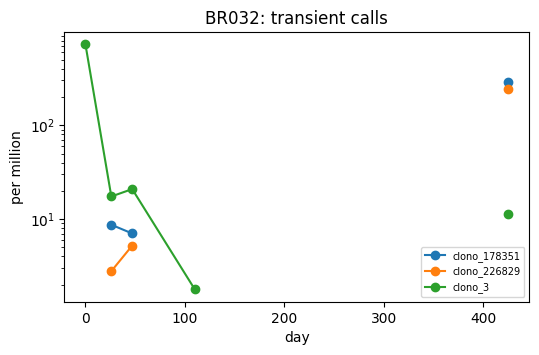

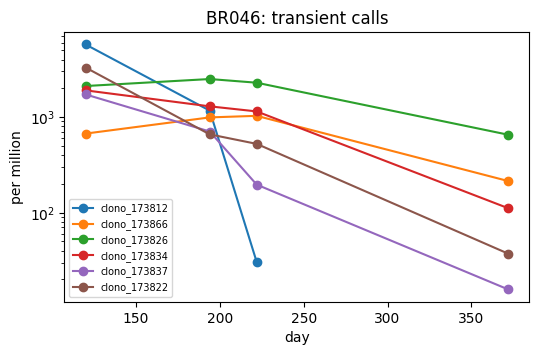

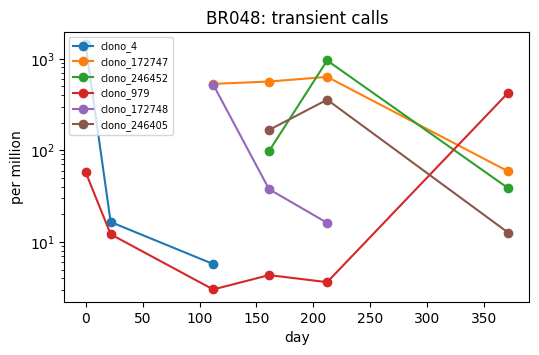

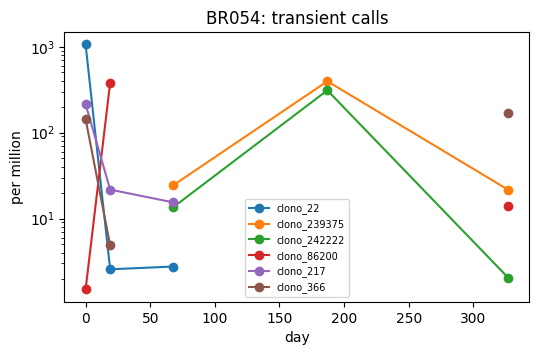

In [20]:
# %% [3d] Trajectories of the transient calls (counts per million, log scale)
import matplotlib.pyplot as plt
tr = pk.sort_values('q_comb').groupby('patient').head(6)
for pat, g in tr.groupby('patient'):
    d = patients_qc[patients_qc['patient'] == pat]
    days = np.sort(d['day'].unique())
    D = d.groupby('day')['D_t'].first().reindex(days)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for cl in g['clono']:
        x = d[d['clono'] == cl].groupby('day')['count'].sum().reindex(days, fill_value=0)
        ax.plot(days, (x / D * 1e6).replace(0, np.nan), marker='o', label=str(cl))
    ax.set_yscale('log'); ax.set_xlabel('day'); ax.set_ylabel('per million')
    ax.set_title(f'{pat}: transient calls'); ax.legend(fontsize=7)
    plt.show()

In [21]:
# %% [3e] OPTIONAL (slow): power for transient clones, quadratic vs slope, on each patient's design
pw_q = nb.spike_in_power(patients_qc, sp_pat, shape='peak', max_clones=5000, n_jobs=-1,
                         test_kwargs={'min_freq': 1e-5, 'design': 'quadratic'})
pw_s = nb.spike_in_power(patients_qc, sp_pat, shape='peak', max_clones=5000, n_jobs=-1,
                         test_kwargs={'min_freq': 1e-5, 'design': 'slope'})
display(pw_q['power'].merge(pw_s['power'][['patient', 'fold', 'band', 'power_all']],
                            on=['patient', 'fold', 'band'], suffixes=('_quad', '_slope')))
display(pw_q['fdr'])

/home/lgavira/Documents/CursoMLMedicina/CursoMLBiomed/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/lgavira/Documents/CursoMLMedicina/CursoMLBiomed/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/lgavira/Documents/CursoMLMedicina/CursoMLBiomed/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/lgavira/Documents/CursoMLMedicina/CursoMLBiomed/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/lgavira/Documents/CursoMLMedicina/CursoMLBiomed/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a,

,patient,fold,band,n_spiked,frac_tested,power_all_quad,power_tested,shape_correct,est_over_true_logfold,peak_day_correct,power_all_slope
0,BR032,2.0,"(-inf, -5.0]",56,0.017857,0.000000,0.000000,NaN,NaN,NaN,0.000000
1,BR032,2.0,"(-5.0, -4.0]",24,0.708333,0.000000,0.000000,NaN,NaN,NaN,0.000000
2,BR032,4.0,"(-inf, -5.0]",36,0.138889,0.000000,0.000000,NaN,NaN,NaN,0.000000
3,BR032,4.0,"(-5.0, -4.0]",15,0.800000,0.000000,0.000000,NaN,NaN,NaN,0.000000
4,BR032,10.0,"(-inf, -5.0]",41,0.365854,0.000000,0.000000,NaN,NaN,NaN,0.000000
5,BR032,10.0,"(-5.0, -4.0]",13,1.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
6,BR032,30.0,"(-inf, -5.0]",40,0.775000,0.050000,0.064516,0.000000,1.572509,0.000000,0.100000
7,BR032,30.0,"(-5.0, -4.0]",19,1.000000,0.105263,0.105263,0.000000,1.983523,0.000000,0.263158
8,BR037,2.0,"(-inf, -5.0]",46,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
9,BR037,2.0,"(-5.0, -4.0]",34,0.205882,0.000000,0.000000,NaN,NaN,NaN,0.000000


,patient,n_calls,false_calls,observed_FDR
0,BR032,4,0,0.0
1,BR037,8,0,0.0
2,BR046,27,0,0.0
3,BR048,14,0,0.0
4,BR052,4,0,0.0
5,BR054,3,0,0.0


R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  
R callback write-console: 2:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  
R callback write-console: 2:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,